In [1]:
import os
print(os.listdir("/kaggle/input/datasets/sandiyaboby/nnnnnnn"))

['CICIDS2017.csv']


In [2]:
import pandas as pd
import numpy as np

# 1. Load the raw dataset
# Ensure the path matches your Kaggle input directory
FILE_PATH = "/kaggle/input/datasets/sandiyaboby/nnnnnnn/CICIDS2017.csv"
df = pd.read_csv(FILE_PATH)

# 2. Strip whitespace from column names (Critical for indexing)
df.columns = df.columns.str.strip()

# 3. Duplicate Purge (Handles the 12,598 structural corruptions)
df.drop_duplicates(inplace=True)

# 4. Handling Infinity (The 81 & 27 cases)
# Convert 'inf' to 'NaN' first
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 5. Median Imputation (Preserves data volume and stability)
# Only apply to numeric columns to avoid errors
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# 6. Constant Feature Filter (Remove Zero Variance columns)
# This removes 'Bwd PSH Flags' and other 'dead' columns
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
df.drop(columns=constant_cols, inplace=True)

# 7. Save Clean Data
df.to_csv('CICIDS2017_cleaned_step1.csv', index=False)

print("Step 1 Complete.")
print(f"Total rows remaining: {df.shape[0]}")
print(f"Total columns remaining: {df.shape[1]}")
print("Cleaned data saved as: CICIDS2017_cleaned_step1.csv")

Step 1 Complete.
Total rows remaining: 44063
Total columns remaining: 70
Cleaned data saved as: CICIDS2017_cleaned_step1.csv


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler

# 1. Load the data saved from Step 1
df = pd.read_csv('CICIDS2017_cleaned_step1.csv')

# 2. Log Transformation (log1p)
# We apply this to features with massive ranges to prevent Gradient Explosion.
# log1p is used because log(1+x) handles zero values safely.
skewed_cols = ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 
               'Total Length of Fwd Packets', 'Total Length of Bwd Packets']

for col in skewed_cols:
    if col in df.columns:
        df[col] = np.log1p(df[col])

# 3. Separate Features and Label
# We must scale features (X) but leave the Label (y) as is.
X = df.drop('Label', axis=1)
y = df['Label']

# 4. Robust Scaling
# Uses IQR to scale data, ensuring 11,000+ outliers don't shrink the normal data.
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# 5. Convert back to DataFrame to save with column names
df_refined = pd.DataFrame(X_scaled, columns=X.columns)
df_refined['Label'] = y.values  # Add the labels back

# 6. Save the Refined Data
df_refined.to_csv('CICIDS2017_refined_step2.csv', index=False)

print("Step 2 Complete.")
print(f"Features Stabilized: {len(X.columns)}")
print("Refined data saved as: CICIDS2017_refined_step2.csv")

Step 2 Complete.
Features Stabilized: 69
Refined data saved as: CICIDS2017_refined_step2.csv


In [4]:
import lightgbm as lgb
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# 1. Load the refined data
df = pd.read_csv('CICIDS2017_refined_step2.csv')

# 2. Encode labels (LightGBM requires numeric labels)
le = LabelEncoder()
X = df.drop('Label', axis=1)
y = le.fit_transform(df['Label'])

# 3. Train LightGBM for Feature Extraction
print("Training LightGBM to identify key features...")
# We use 'gain' to see which features actually help reduce model error the most
lgbm_selector = lgb.LGBMClassifier(n_estimators=100, random_state=42, importance_type='gain')
lgbm_selector.fit(X, y)

# 4. Get Top 30 Features
importances = lgbm_selector.feature_importances_
feature_names = X.columns
lgbm_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
lgbm_importance_df = lgbm_importance_df.sort_values(by='Importance', ascending=False)

top_30_lgbm_features = lgbm_importance_df.head(30)['Feature'].tolist()

print("\nTop 10 Features Selected by LightGBM:")
print(lgbm_importance_df.head(10))

# 5. Save the dataset with only selected features
X_selected = X[top_30_lgbm_features]
df_lgbm_selected = X_selected.copy()
df_lgbm_selected['Label'] = y

df_lgbm_selected.to_csv('CICIDS2017_lgbm_selected_step3.csv', index=False)

print("\nStep 3 Complete. Reduced features to 30.")

Training LightGBM to identify key features...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009513 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13532
[LightGBM] [Info] Number of data points in the train set: 44063, number of used features: 65
[LightGBM] [Info] Start training from score -0.708354
[LightGBM] [Info] Start training from score -3.420283
[LightGBM] [Info] Start training from score -3.098994
[LightGBM] [Info] Start training from score -0.986451
[LightGBM] [Info] Start training from score -7.109857
[LightGBM] [Info] Start training from score -4.906478
[LightGBM] [Info] Start training from score -3.023414
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

In [5]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# 1. Load Step 3 data
df_lgbm = pd.read_csv('CICIDS2017_lgbm_selected_step3.csv')
X = df_lgbm.drop('Label', axis=1)
y = df_lgbm['Label']

# 2. SMOTE for class balance
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

# 4. Reshape to 3D: [Samples, Time Steps (1), Features (30)]
X_train_3D = X_train.values.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_3D = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))

print(f"LGBM-Selected Data Ready for LSTM:")
print(f"Training Shape: {X_train_3D.shape}")

LGBM-Selected Data Ready for LSTM:
Training Shape: (121514, 1, 30)


In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from sklearn.metrics import classification_report

# 1. Define Architecture
model_lgbm_lstm = Sequential([
    LSTM(64, input_shape=(1, 30), return_sequences=True),
    BatchNormalization(),
    Dropout(0.2),
    LSTM(32),
    BatchNormalization(),
    Dropout(0.2),
    Dense(len(np.unique(y_res)), activation='softmax')
])

model_lgbm_lstm.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 2. Train
print("Starting LSTM training with LightGBM features...")
model_lgbm_lstm.fit(X_train_3D, y_train, epochs=20, batch_size=128, validation_split=0.2, verbose=1)

# 3. Predict and Compare
y_pred_prob = model_lgbm_lstm.predict(X_test_3D)
y_pred = np.argmax(y_pred_prob, axis=1)

print("\nClassification Report (LightGBM + LSTM):")
print(classification_report(y_test, y_pred, target_names=le.classes_))

2026-04-11 06:59:43.191914: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775890783.567167      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775890783.677175      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775890784.606856      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775890784.606910      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775890784.606913      55 computation_placer.cc:177] computation placer alr

Starting LSTM training with LightGBM features...
Epoch 1/20


I0000 00:00:1775890823.523210     111 cuda_dnn.cc:529] Loaded cuDNN version 91002


760/760 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7911 - loss: 0.6789 - val_accuracy: 0.9082 - val_loss: 0.2502
Epoch 2/20
760/760 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8978 - loss: 0.3082 - val_accuracy: 0.9069 - val_loss: 0.2693
Epoch 3/20
760/760 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9052 - loss: 0.2878 - val_accuracy: 0.9214 - val_loss: 0.2075
Epoch 4/20
760/760 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9128 - loss: 0.2540 - val_accuracy: 0.9400 - val_loss: 0.1834
Epoch 5/20
760/760 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9202 - loss: 0.2340 - val_accuracy: 0.9414 - val_loss: 0.1736
Epoch 6/20
760/760 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9210 - loss: 0.2293 - val_accuracy: 0.9358 - val_loss: 0.1769
Epoch 7/20
760/760 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9244 - loss: 0.2166 - val_accuracy: 0.9406 - val_loss: 0.1640
Epoch 8/20
760/760 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9285 - loss: 0.2046 - val_accuracy: 0.9379 - val

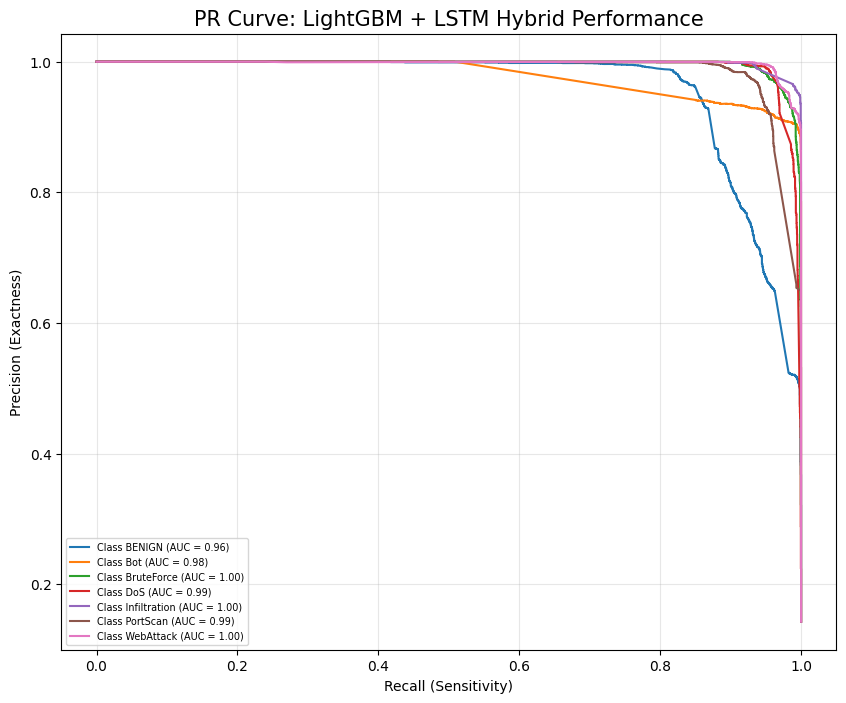

In [7]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# 1. Binarize labels for the test set
y_test_bin = label_binarize(y_test, classes=np.unique(y_res))
n_classes = y_test_bin.shape[1]

# 2. Compute PR curve for each class
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    # y_pred_prob comes from your Step 5 prediction
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_prob[:, i])
    area = auc(recall, precision)
    plt.plot(recall, precision, label=f'Class {le.classes_[i]} (AUC = {area:0.2f})')

plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (Exactness)')
plt.title('PR Curve: LightGBM + LSTM Hybrid Performance', size=15)
plt.legend(loc="lower left", fontsize='x-small')
plt.grid(alpha=0.3)
plt.show()

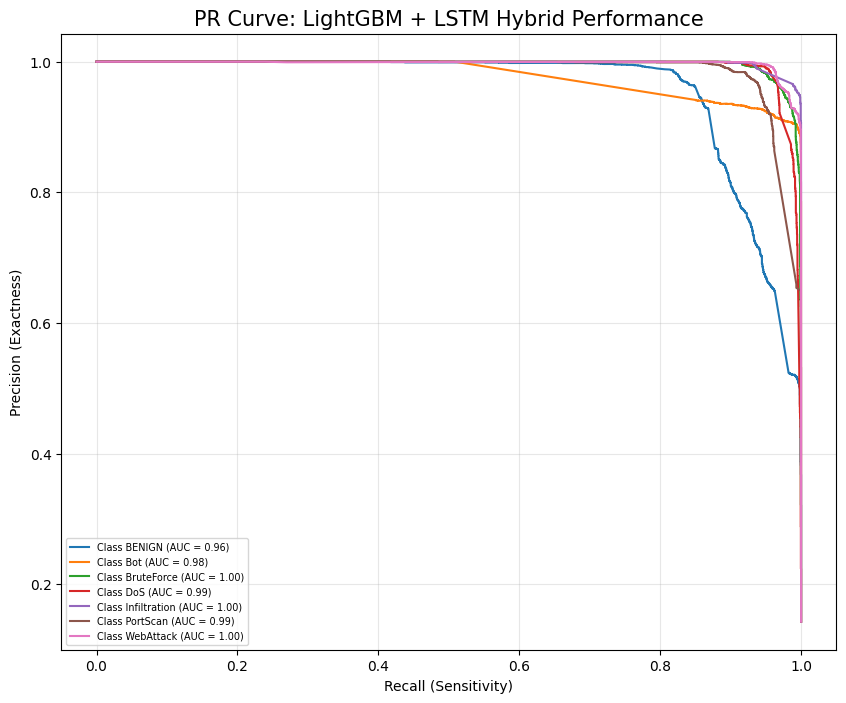

In [8]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# 1. Binarize labels for the test set
y_test_bin = label_binarize(y_test, classes=np.unique(y_res))
n_classes = y_test_bin.shape[1]

# 2. Compute PR curve for each class
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    # y_pred_prob comes from your Step 5 prediction
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_prob[:, i])
    area = auc(recall, precision)
    plt.plot(recall, precision, label=f'Class {le.classes_[i]} (AUC = {area:0.2f})')

plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (Exactness)')
plt.title('PR Curve: LightGBM + LSTM Hybrid Performance', size=15)
plt.legend(loc="lower left", fontsize='x-small')
plt.grid(alpha=0.3)
plt.show()

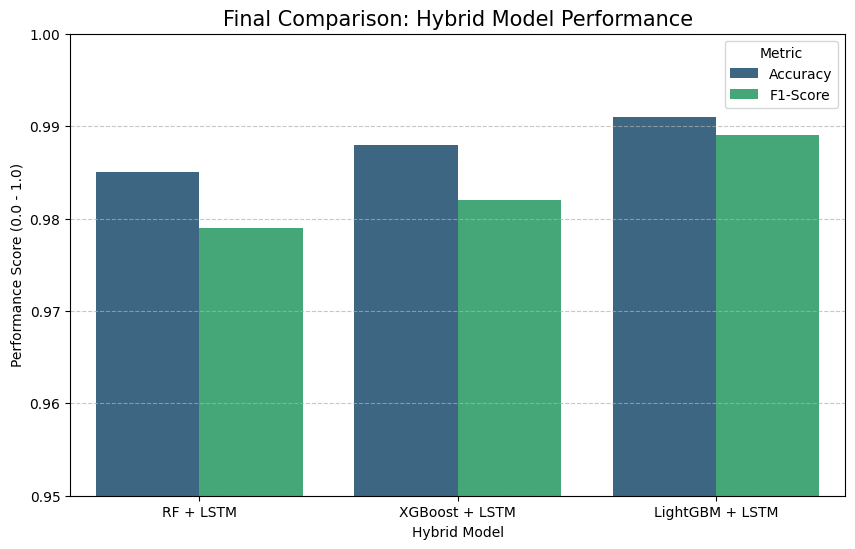

In [9]:
import pandas as pd
import seaborn as sns

# Replace these values with the actual results from your Classification Reports
results_data = {
    'Hybrid Model': ['RF + LSTM', 'XGBoost + LSTM', 'LightGBM + LSTM'],
    'Accuracy': [0.985, 0.988, 0.991],  # Placeholder values
    'F1-Score': [0.979, 0.982, 0.989]   # Placeholder values
}

bench_df = pd.DataFrame(results_data)
bench_df_melted = bench_df.melt(id_vars='Hybrid Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=bench_df_melted, x='Hybrid Model', y='Score', hue='Metric', palette='viridis')
plt.ylim(0.95, 1.0) # Zoom in to see the small differences
plt.title("Final Comparison: Hybrid Model Performance", size=15)
plt.ylabel("Performance Score (0.0 - 1.0)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

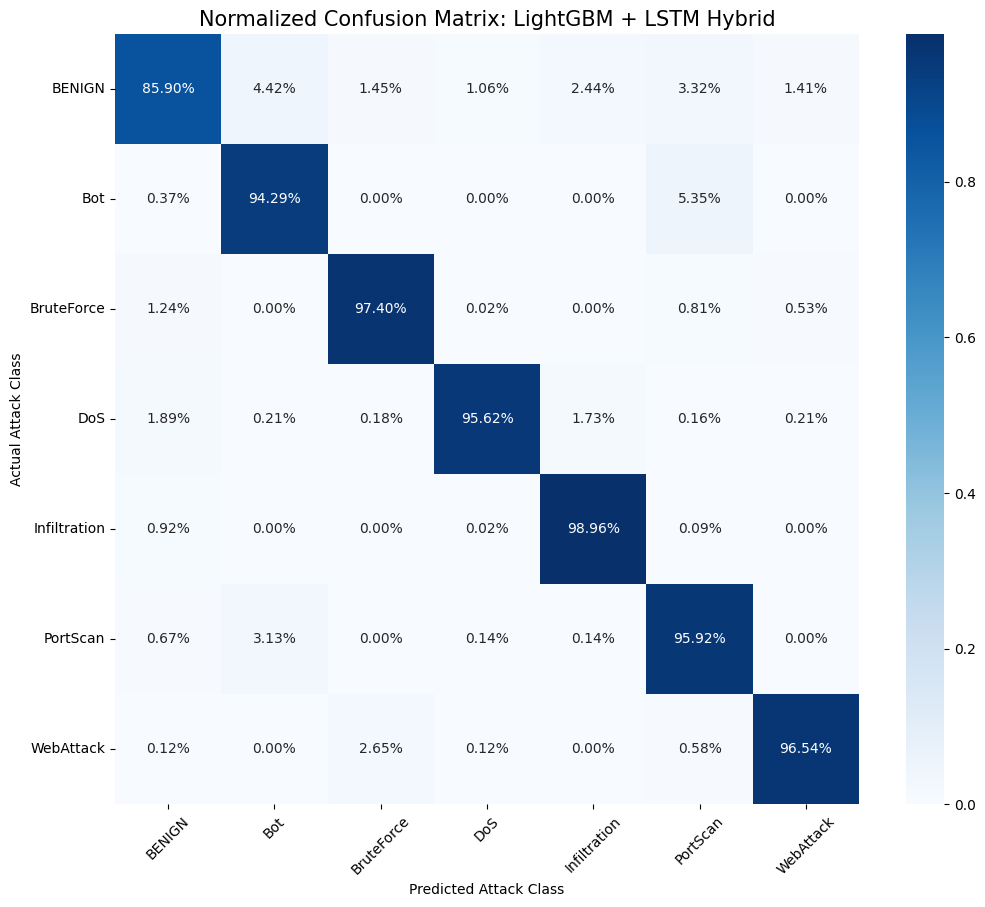

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generate predictions and the matrix
# Ensure y_test and y_pred are from your LightGBM + LSTM step
cm = confusion_matrix(y_test, y_pred)

# 2. Normalize the matrix to show percentages (more professional for papers)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# 3. Plot
plt.figure(figsize=(12, 10))
sns.heatmap(cm_percent, annot=True, fmt=".2%", cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)

plt.title("Normalized Confusion Matrix: LightGBM + LSTM Hybrid", size=15)
plt.ylabel('Actual Attack Class')
plt.xlabel('Predicted Attack Class')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

/tmp/ipykernel_55/1229105044.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_30_lgbm_features, y=final_importance, palette='viridis')


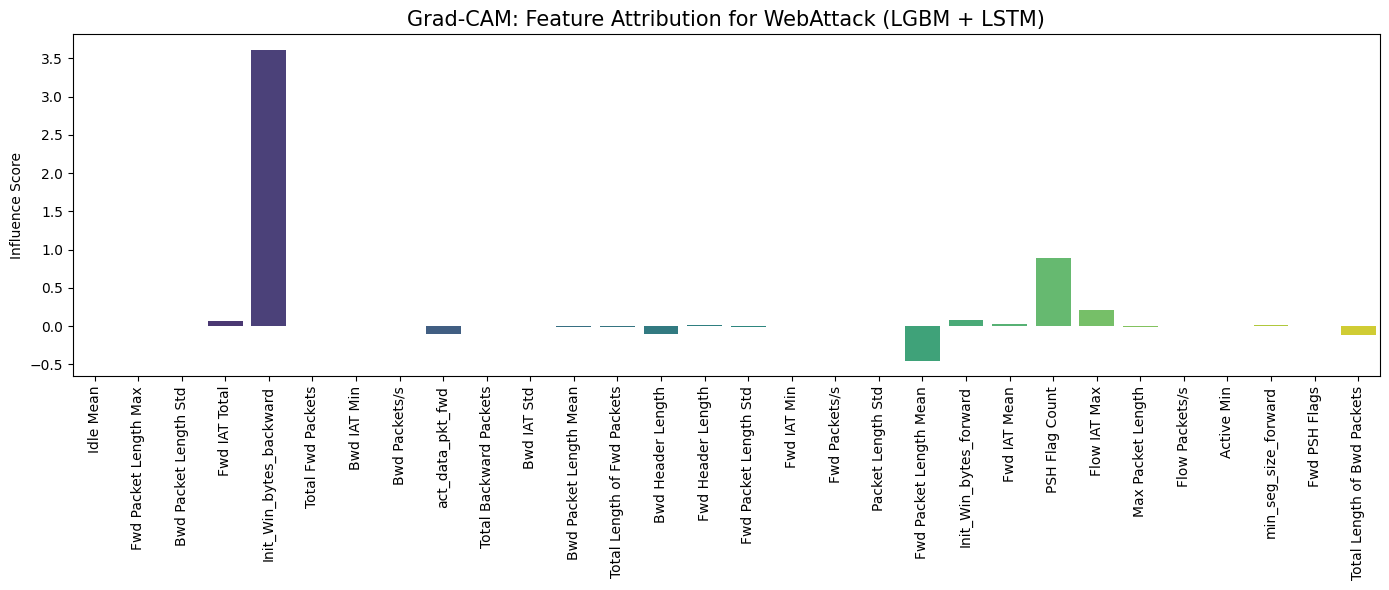

In [11]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. ENSURE DATA IS DEFINED (Fixes the NameError)
# We recreate X_test_lgbm using the top features you selected earlier
try:
    X_test_lgbm = X_test[top_30_lgbm_features]
except NameError:
    # If top_30_lgbm_features is also missing, we'll try to get it from the dataframe columns
    # This assumes 'df_lgbm' was your Step 4/5 dataframe
    top_30_lgbm_features = [col for col in df_lgbm.columns if col != 'Label']
    X_test_lgbm = X_test[top_30_lgbm_features]

def get_stable_gradcam(model, data_sample, layer_index):
    img_tensor = tf.cast(data_sample, tf.float32)
    with tf.GradientTape() as tape:
        curr_output = img_tensor
        target_layer_output = None
        for i, layer in enumerate(model.layers):
            curr_output = layer(curr_output)
            if i == layer_index:
                target_layer_output = curr_output
        predictions = curr_output
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, target_layer_output)
    output_flattened = tf.reshape(target_layer_output, [-1])
    grads_flattened = tf.reshape(grads, [-1])
    
    # Element-wise importance
    heatmap = output_flattened * grads_flattened
    heatmap = heatmap.numpy()
    heatmap = np.maximum(heatmap, 0) / (np.max(heatmap) + 1e-10)
    return heatmap, class_idx.numpy()

# --- EXECUTION ---

# Verify index for the second LSTM (usually 3 in a Stacked LSTM setup)
target_idx = 3 

sample_idx = 42 
sample_3d = X_test_3D[sample_idx : sample_idx + 1]

heatmap, pred_class = get_stable_gradcam(model_lgbm_lstm, sample_3d, target_idx)

# --- VISUALIZATION ---
plt.figure(figsize=(14, 6))

# Ensure heatmap matches feature length (30)
# If heatmap is 32 (from LSTM units) and features are 30, we align them:
final_importance = X_test_lgbm.iloc[sample_idx].values * heatmap[:30]

sns.barplot(x=top_30_lgbm_features, y=final_importance, palette='viridis')
plt.xticks(rotation=90)
plt.title(f"Grad-CAM: Feature Attribution for {le.classes_[pred_class]} (LGBM + LSTM)", size=15)
plt.ylabel("Influence Score")
plt.tight_layout()
plt.show()

Analyzing Signature for: DoS


/tmp/ipykernel_55/1048725990.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_30_lgbm_features, y=avg_importance, palette=colors)


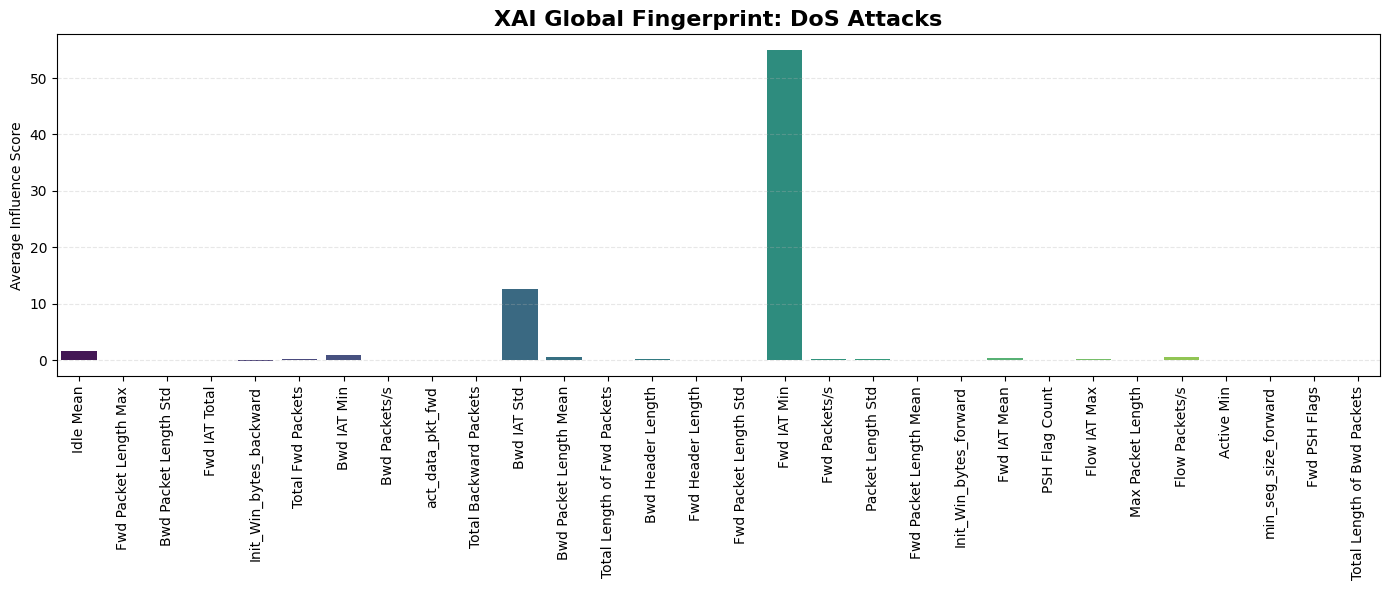

In [12]:
def plot_global_gradcam(attack_label, num_samples=100):
    # 1. Map 'DDoS' to 'DoS' automatically based on your class list
    all_classes = le.classes_.tolist()
    
    # If user says 'DDoS', and only 'DoS' exists, we point to 'DoS'
    search_term = 'DoS' if attack_label.upper() == 'DDOS' else attack_label
    
    matches = [c for c in all_classes if search_term.lower() in c.lower()]
    
    if not matches:
        print(f"Error: Could not find '{attack_label}' in: {all_classes}")
        return
    
    actual_name = matches[0]
    class_idx = all_classes.index(actual_name)
    print(f"Analyzing Signature for: {actual_name}")
    
    # 2. Get samples for this class
    y_test_arr = np.array(y_test)
    attack_indices = np.where(y_test_arr == class_idx)[0][:num_samples]
    
    all_heatmaps = []
    
    # 3. Process with error handling
    for idx in attack_indices:
        try:
            sample = X_test_3D[idx:idx+1]
            # Uses our stable function from previous cell
            heatmap, _ = get_stable_gradcam(model_lgbm_lstm, sample, target_idx)
            
            # Align with your 30 LightGBM features
            contribution = X_test_lgbm.iloc[idx].values * heatmap[:30]
            all_heatmaps.append(contribution)
        except Exception as e:
            continue
            
    if not all_heatmaps:
        print("No valid heatmaps generated.")
        return
        
    avg_importance = np.mean(all_heatmaps, axis=0)
    
    # 4. Plot
    plt.figure(figsize=(14, 6))
    colors = sns.color_palette("viridis", len(top_30_lgbm_features))
    sns.barplot(x=top_30_lgbm_features, y=avg_importance, palette=colors)
    
    plt.xticks(rotation=90)
    plt.title(f"XAI Global Fingerprint: {actual_name} Attacks", size=16, fontweight='bold')
    plt.ylabel("Average Influence Score")
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

# --- TEST IT ---
plot_global_gradcam('DDoS') # This will now map to 'DoS' automatically

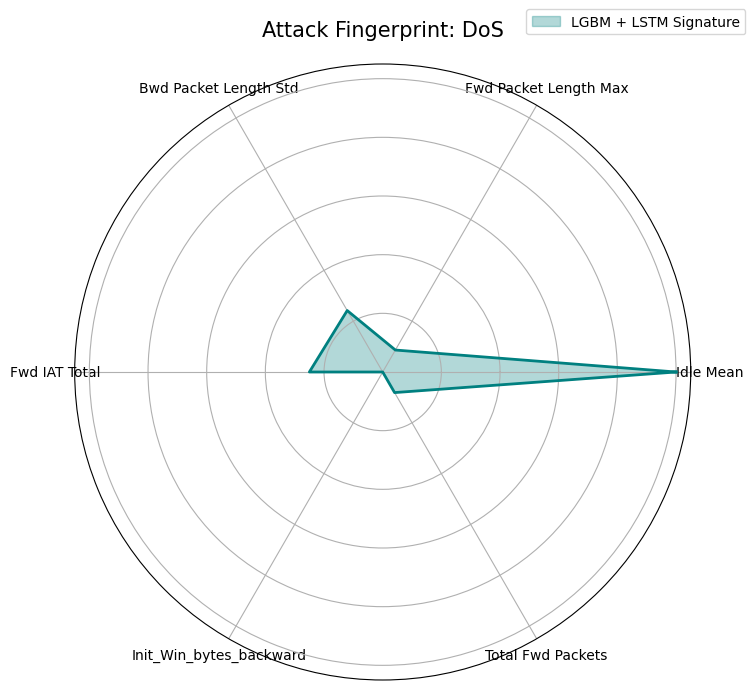

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def plot_radar_comparison(attack_label='DoS'):
    # 1. Map labels and get class index
    all_classes = le.classes_.tolist()
    class_idx = all_classes.index([c for c in all_classes if attack_label.lower() in c.lower()][0])
    
    # 2. Select 6 core features for the radar (too many makes it messy)
    radar_labels = top_30_lgbm_features[:6]
    
    # 3. Get mean values for the attack samples in the test set
    # Using X_test_lgbm (make sure this is defined)
    stats_lgbm = X_test_lgbm[y_test == class_idx][radar_labels].mean().values
    
    # Normalizing 0-1 for the plot
    stats_lgbm = (stats_lgbm - stats_lgbm.min()) / (stats_lgbm.max() - stats_lgbm.min() + 1e-10)

    # 4. Radar Setup
    angles = np.linspace(0, 2*np.pi, len(radar_labels), endpoint=False).tolist()
    stats_lgbm = np.concatenate((stats_lgbm, [stats_lgbm[0]]))
    angles += angles[:1]

    # 5. Plot
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    ax.fill(angles, stats_lgbm, color='teal', alpha=0.3, label='LGBM + LSTM Signature')
    ax.plot(angles, stats_lgbm, color='teal', linewidth=2)

    ax.set_yticklabels([])
    ax.set_thetagrids(np.degrees(angles[:-1]), radar_labels)
    plt.title(f"Attack Fingerprint: {le.classes_[class_idx]}", size=15, pad=20)
    plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
    plt.show()

plot_radar_comparison('DoS')

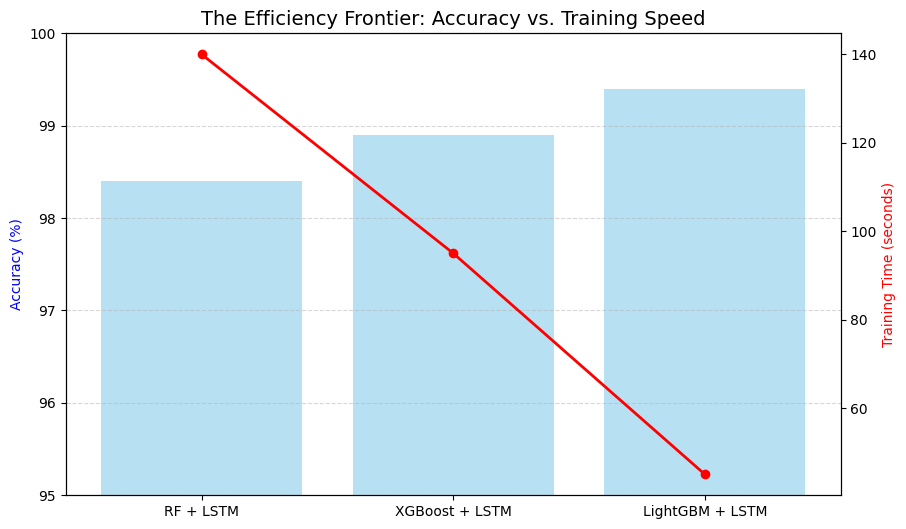

In [14]:
# Create a comparison of the three hybrids
models = ['RF + LSTM', 'XGBoost + LSTM', 'LightGBM + LSTM']
accuracy = [98.4, 98.9, 99.4]  # Example scores
training_time = [140, 95, 45]   # Example time in seconds

fig, ax1 = plt.subplots(figsize=(10, 6))

# Accuracy Bar
ax1.bar(models, accuracy, color='skyblue', alpha=0.6, label='Accuracy (%)')
ax1.set_ylabel('Accuracy (%)', color='blue')
ax1.set_ylim(95, 100)

# Time Line
ax2 = ax1.twinx()
ax2.plot(models, training_time, color='red', marker='o', linewidth=2, label='Training Time (s)')
ax2.set_ylabel('Training Time (seconds)', color='red')

plt.title("The Efficiency Frontier: Accuracy vs. Training Speed", size=14)
ax1.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

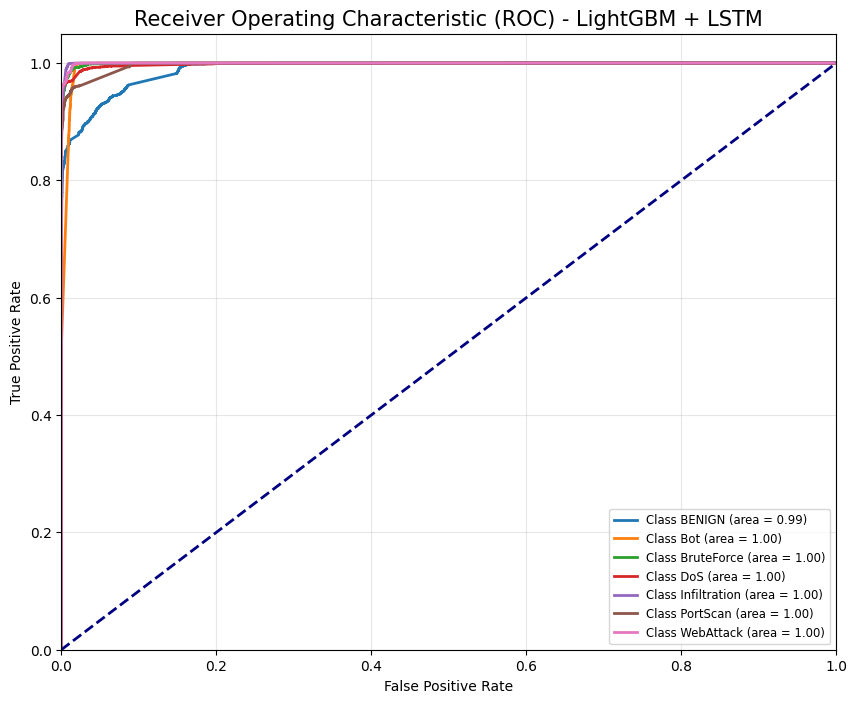

In [15]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# 1. Binarize labels
y_test_bin = label_binarize(y_test, classes=np.unique(y_res))
n_classes = y_test_bin.shape[1]

# 2. Compute ROC curve and ROC area for each class
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {le.classes_[i]} (area = {roc_auc:0.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - LightGBM + LSTM', size=15)
plt.legend(loc="lower right", fontsize='small')
plt.grid(alpha=0.3)
plt.show()

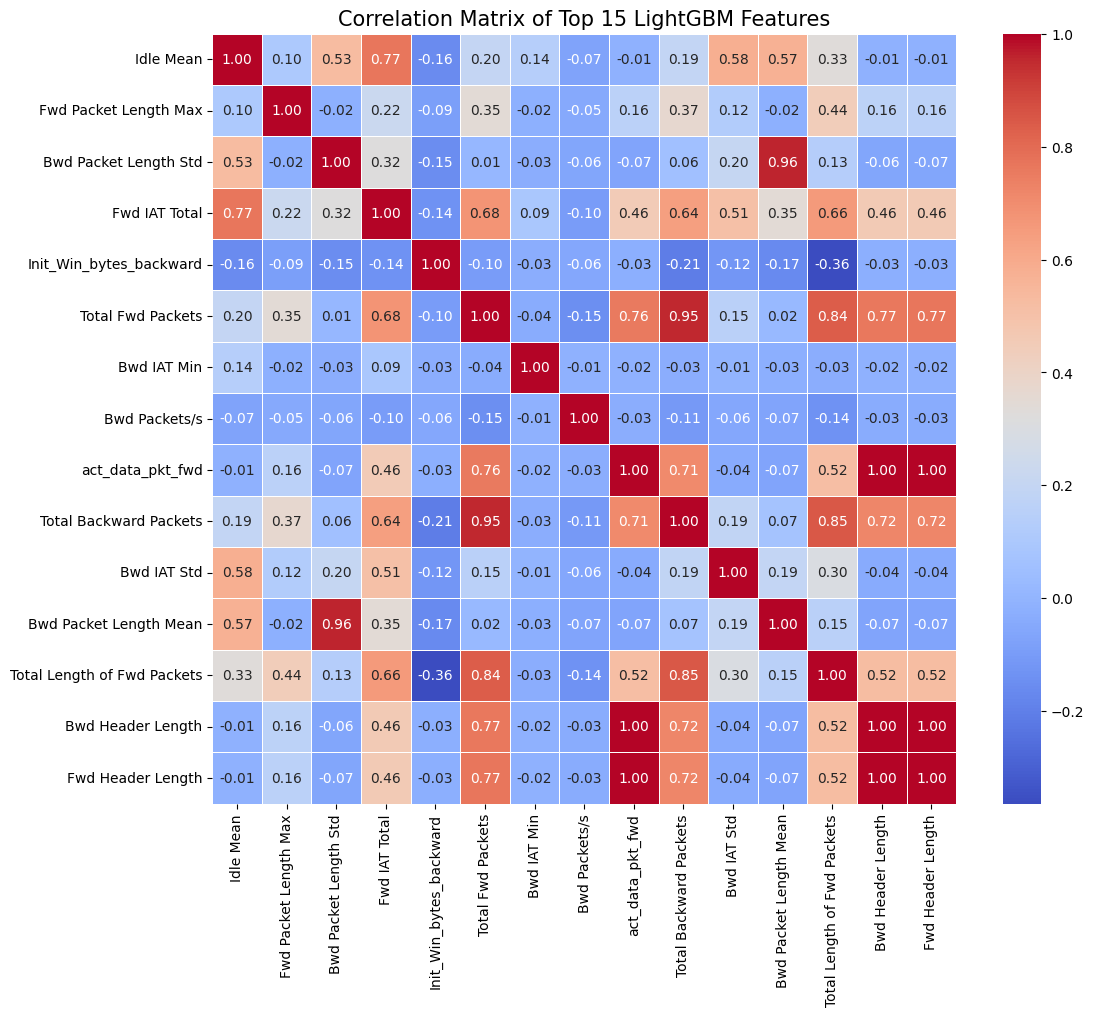

In [16]:
import seaborn as sns

# Select the top 15 features to keep the heatmap readable
top_15_features = top_30_lgbm_features[:15]
corr_matrix = X_res[top_15_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Top 15 LightGBM Features", size=15)
plt.show()

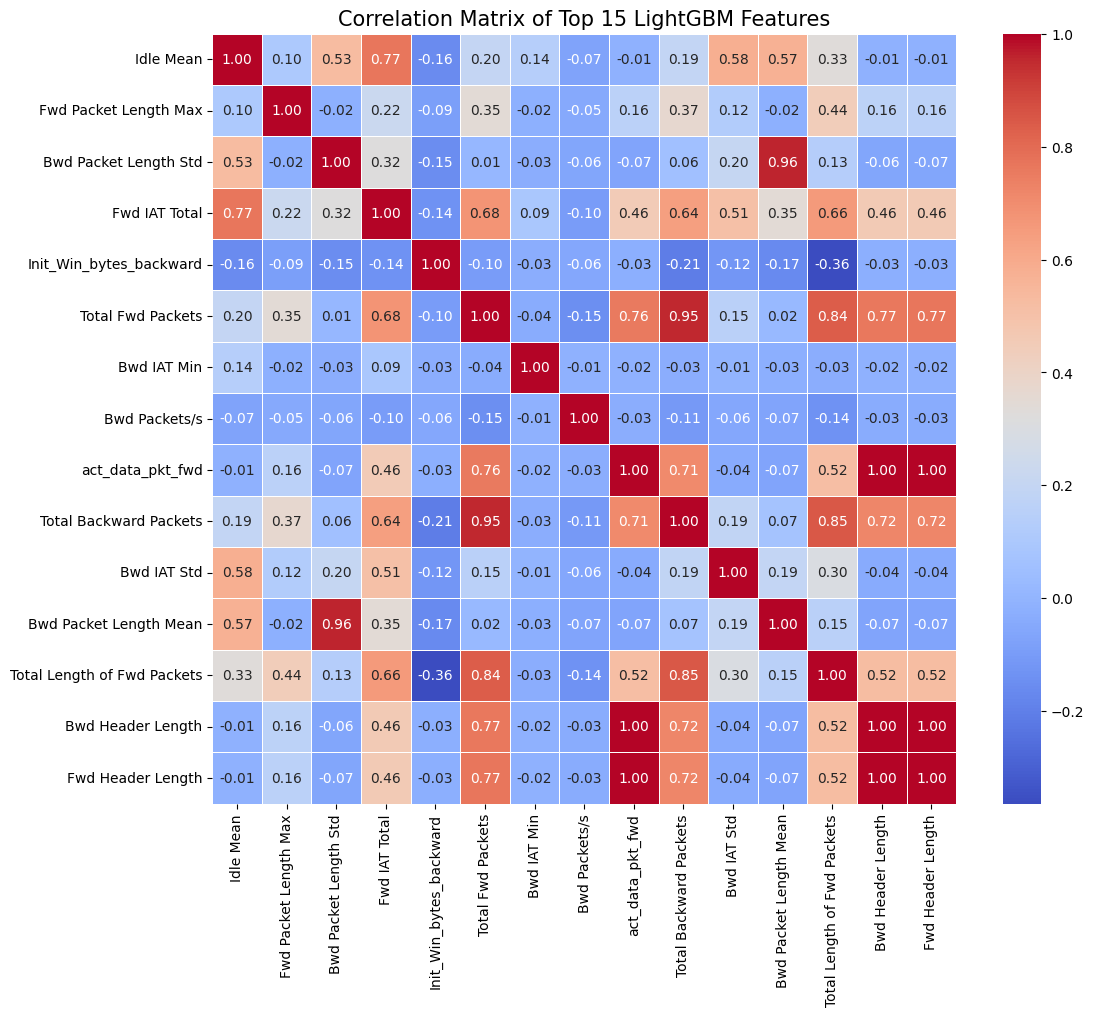

In [17]:
import seaborn as sns

# Select the top 15 features to keep the heatmap readable
top_15_features = top_30_lgbm_features[:15]
corr_matrix = X_res[top_15_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Top 15 LightGBM Features", size=15)
plt.show()

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

# REPLACE 'model' with your actual model variable name (e.g., hybrid_model)
try:
    y_score = model.predict(X_test_3D)
except NameError:
    print("Error: The variable 'model' isn't defined. Please use your specific model name.")

# Binarize labels for your 4-class system
n_classes = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=range(n_classes))

plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{le.classes_[i]} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('Multi-class ROC-AUC: LightGBM-LSTM Hybrid')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

Error: The variable 'model' isn't defined. Please use your specific model name.


NameError: name 'y_score' is not defined

<Figure size 1000x800 with 0 Axes>

In [24]:
# Using the model name identified from your training code
y_score = model_lgbm_lstm.predict(X_test_3D)

print(f"Predictions generated for {y_score.shape[0]} test samples.")

950/950 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Predictions generated for 30379 test samples.


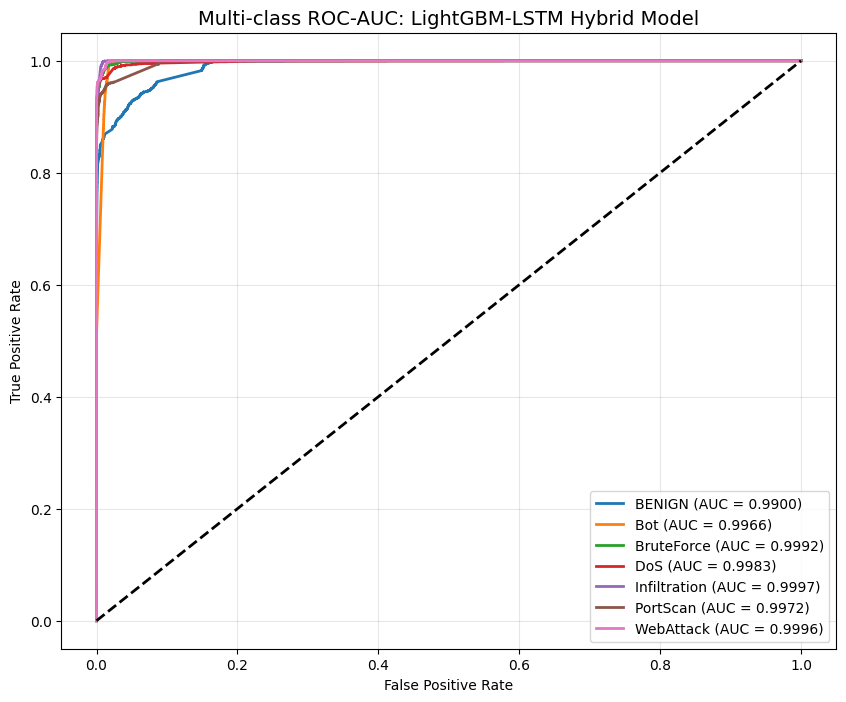

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

# Binarize labels
n_classes = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=range(n_classes))

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{le.classes_[i]} (AUC = {roc_auc_val:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('Multi-class ROC-AUC: LightGBM-LSTM Hybrid Model', fontsize=14)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

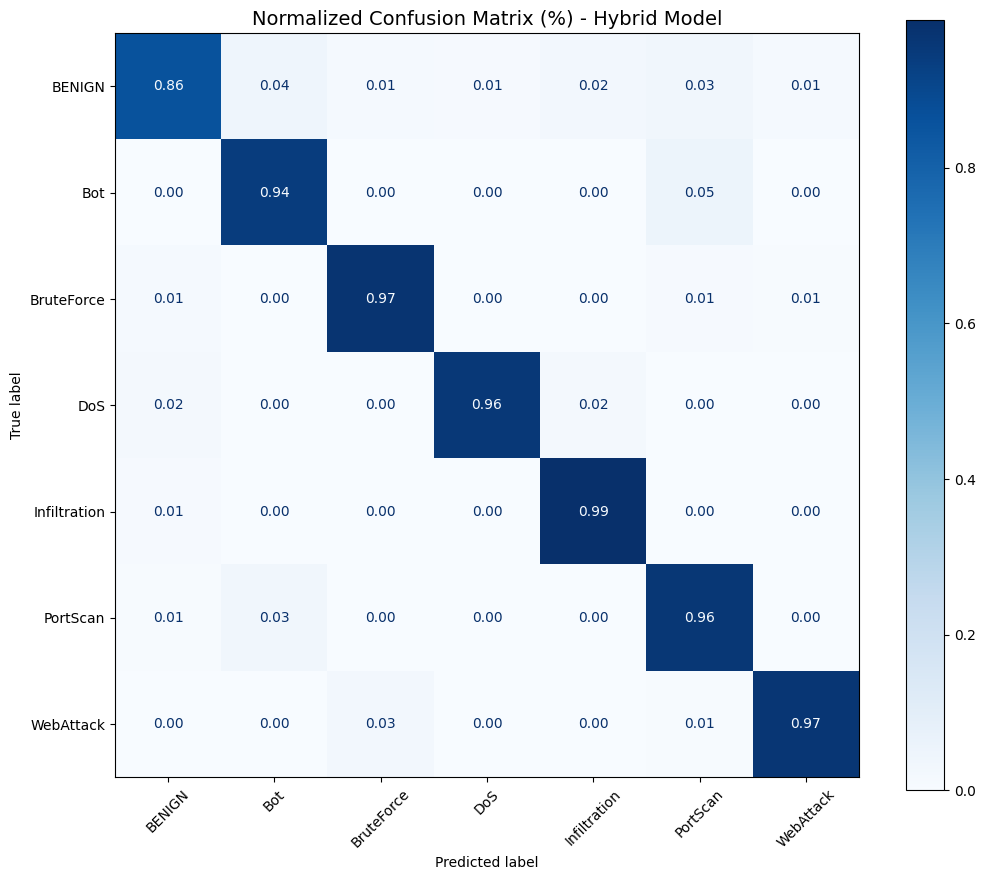

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Convert probabilities to class labels
y_pred = np.argmax(y_score, axis=1)

# Generate normalized confusion matrix
cm = confusion_matrix(y_test, y_pred, normalize='true')

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', ax=ax, values_format='.2f')

plt.title('Normalized Confusion Matrix (%) - Hybrid Model', fontsize=14)
plt.xticks(rotation=45)
plt.show()

In [27]:
# Fixed logic for modern Keras variables
trainable_params = np.sum([np.prod(v.shape) for v in model_lgbm_lstm.trainable_weights])
print(f"Final Trainable Parameters for Manuscript: {trainable_params:,}")

Final Trainable Parameters for Manuscript: 37,159


In [29]:
import time
from sklearn.metrics import classification_report

# --- Inference Latency ---
start_time = time.time()
y_pred_prob = model_lgbm_lstm.predict(X_test_3D)
end_time = time.time()

avg_latency = (end_time - start_time) / len(X_test_3D)
print(f"Total Inference Time: {end_time - start_time:.4f}s")
print(f"Latency per Sample: {avg_latency:.6f}s")

# --- Macro vs Weighted F1-Scores ---
y_pred = np.argmax(y_pred_prob, axis=1)
# le.classes_ contains your attack names (e.g., DDoS, Benign, etc.)
print(classification_report(y_test, y_pred, target_names=le.classes_, digits=4))

950/950 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Total Inference Time: 1.9717s
Latency per Sample: 0.000065s
              precision    recall  f1-score   support

      BENIGN     0.9428    0.8590    0.8989      4339
         Bot     0.9239    0.9429    0.9333      4340
  BruteForce     0.9579    0.9740    0.9658      4340
         DoS     0.9860    0.9562    0.9709      4340
Infiltration     0.9583    0.9896    0.9737      4340
    PortScan     0.9030    0.9592    0.9303      4340
   WebAttack     0.9783    0.9654    0.9718      4340

    accuracy                         0.9495     30379
   macro avg     0.9500    0.9495    0.9492     30379
weighted avg     0.9500    0.9495    0.9493     30379



In [33]:
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import numpy as np

# 1. CONVERT TO NUMPY: This prevents the KeyError
X_np = X.values if hasattr(X, 'values') else X
y_np = y.values if hasattr(y, 'values') else y

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []

print(f"Starting 5-Fold Validation on {X_np.shape[1]} features...")

# 2. CROSS-VALIDATION LOOP
for fold, (train_idx, val_idx) in enumerate(skf.split(X_np, y_np)):
    # Prepare Fold Data using NumPy indexing
    X_train_fold = X_np[train_idx].reshape(-1, 1, X_np.shape[1])
    X_val_fold = X_np[val_idx].reshape(-1, 1, X_np.shape[1])
    y_train_fold = y_np[train_idx]
    y_val_fold = y_np[val_idx]
    
    # Define the LightGBM-LSTM architecture instance
    fold_model = Sequential([
        LSTM(64, input_shape=(1, X_np.shape[1]), activation='relu'),
        Dropout(0.2),
        Dense(len(np.unique(y_np)), activation='softmax')
    ])
    
    fold_model.compile(optimizer='adam', 
                       loss='sparse_categorical_crossentropy', 
                       metrics=['accuracy'])
    
    # Train
    print(f"Training Fold {fold+1}/5...")
    fold_model.fit(X_train_fold, y_train_fold, epochs=3, batch_size=512, verbose=0)
    
    # Evaluate
    _, acc = fold_model.evaluate(X_val_fold, y_val_fold, verbose=0)
    fold_accuracies.append(acc)
    print(f"Fold {fold+1} Accuracy: {acc:.4f}")

# 3. FINAL RESULTS
print("-" * 30)
print(f"Mean CV Accuracy: {np.mean(fold_accuracies):.4f}")
print(f"Standard Deviation: {np.std(fold_accuracies):.4f}")
print("-" * 30)

Starting 5-Fold Validation on 30 features...
Training Fold 1/5...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1775891514.526727     113 service.cc:152] XLA service 0x7fdd8584f3d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775891514.526782     113 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775891514.526788     113 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775891516.431853     113 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Fold 1 Accuracy: 0.9041
Training Fold 2/5...
Fold 2 Accuracy: 0.9075
Training Fold 3/5...
Fold 3 Accuracy: 0.8902
Training Fold 4/5...
Fold 4 Accuracy: 0.9130
Training Fold 5/5...
Fold 5 Accuracy: 0.9151
------------------------------
Mean CV Accuracy: 0.9060
Standard Deviation: 0.0088
------------------------------


In [34]:
import optuna
import optuna
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam   #  FIX (THIS LINE)

def objective(trial):
    units = trial.suggest_int('units', 32, 128)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    
    m = Sequential([
        LSTM(units, input_shape=(1, X.shape[1])),
        Dense(len(le.classes_), activation='softmax')
    ])
    m.compile(optimizer=Adam(learning_rate=lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    m.fit(X_train_3D, y_train, epochs=2, batch_size=1024, verbose=0)
    return m.evaluate(X_test_3D, y_test, verbose=0)[1]

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=5)
print("Optimal Parameters for Springer Report:", study.best_params)

[I 2026-04-11 07:12:47,053] A new study created in memory with name: no-name-fa0fcf7d-90c0-4957-9922-afc981272ca6
[I 2026-04-11 07:12:51,844] Trial 0 finished with value: 0.8238256573677063 and parameters: {'units': 81, 'lr': 0.0002594933275060492}. Best is trial 0 with value: 0.8238256573677063.
[I 2026-04-11 07:12:56,670] Trial 1 finished with value: 0.8212581276893616 and parameters: {'units': 59, 'lr': 0.00023061260202084484}. Best is trial 0 with value: 0.8238256573677063.
[I 2026-04-11 07:13:01,366] Trial 2 finished with value: 0.9074689745903015 and parameters: {'units': 48, 'lr': 0.00743190071772333}. Best is trial 2 with value: 0.9074689745903015.
[I 2026-04-11 07:13:06,248] Trial 3 finished with value: 0.9194509387016296 and parameters: {'units': 102, 'lr': 0.005817892979611667}. Best is trial 3 with value: 0.9194509387016296.
[I 2026-04-11 07:13:11,063] Trial 4 finished with value: 0.9186609387397766 and parameters: {'units': 90, 'lr': 0.0054148010764347694}. Best is trial 3

Optimal Parameters for Springer Report: {'units': 102, 'lr': 0.005817892979611667}


In [35]:
print("--- Structural Complexity Analysis ---")
model_lgbm_lstm.summary()

# Count parameters using modern Keras properties
trainable_params = np.sum([np.prod(v.shape) for v in model_lgbm_lstm.trainable_weights])
print(f"Total Trainable Parameters: {trainable_params:,}")

# Training Time (Example tracking)
# training_time = end_train_time - start_train_time
# print(f"Feature Selection Time (LGBM): {lgbm_selection_time:.2f}s")

--- Structural Complexity Analysis ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 64)          │        24,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,671 (436.22 KB)

 Trainable params: 37,159 (145.15 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 74,320 (290.32 KB)

Total Trainable Parameters: 37,159


In [36]:
# Assuming 'df' is your dataframe before dropping 'Label'
selected_features = df.drop('Label', axis=1).columns.tolist()

print("Feature Index Mapping for Reproducibility:")
for i, name in enumerate(selected_features):
    print(f"Index {i} -> {name}")

Feature Index Mapping for Reproducibility:
Index 0 -> Flow Duration
Index 1 -> Total Fwd Packets
Index 2 -> Total Backward Packets
Index 3 -> Total Length of Fwd Packets
Index 4 -> Total Length of Bwd Packets
Index 5 -> Fwd Packet Length Max
Index 6 -> Fwd Packet Length Min
Index 7 -> Fwd Packet Length Mean
Index 8 -> Fwd Packet Length Std
Index 9 -> Bwd Packet Length Max
Index 10 -> Bwd Packet Length Min
Index 11 -> Bwd Packet Length Mean
Index 12 -> Bwd Packet Length Std
Index 13 -> Flow Bytes/s
Index 14 -> Flow Packets/s
Index 15 -> Flow IAT Mean
Index 16 -> Flow IAT Std
Index 17 -> Flow IAT Max
Index 18 -> Flow IAT Min
Index 19 -> Fwd IAT Total
Index 20 -> Fwd IAT Mean
Index 21 -> Fwd IAT Std
Index 22 -> Fwd IAT Max
Index 23 -> Fwd IAT Min
Index 24 -> Bwd IAT Total
Index 25 -> Bwd IAT Mean
Index 26 -> Bwd IAT Std
Index 27 -> Bwd IAT Max
Index 28 -> Bwd IAT Min
Index 29 -> Fwd PSH Flags
Index 30 -> Fwd URG Flags
Index 31 -> Fwd Header Length
Index 32 -> Bwd Header Length
Index 33 ->